# Imports

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
from tqdm import tqdm
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy import units as u
from scipy.stats import skew

# Configuration of data

In [3]:
MAX_SAMPLES = 10000  # Number of TESS objects to process
MIN_PERIOD = 0.1   
MAX_PERIOD = 15.0  
GAIA_SEARCH_RADIUS = 2  

# Data processing functions

In [5]:
def process_tess_data(max_samples=MAX_SAMPLES, enrich_with_gaia=True):
    """
    Process TESS light curves and optionally enrich with GAIA data.
    
    Returns:
    --------
    list: List of dictionaries containing TESS + GAIA data for each star
    """
    print("Loading TESS dataset...")
    tess_data = load_dataset("MultimodalUniverse/tess", split="train", streaming=True)
    print("Loaded successfully!\n")
    
    results = []
    
    print(f"Processing up to {max_samples} light curves...")
    for i, sample in enumerate(tqdm(tess_data, total=max_samples)):
        if i >= max_samples:
            break
        
        try:
            lc = sample['lightcurve']
            time = np.array(lc['time'])
            flux = np.array(lc['flux'])
            flux_err = np.array(lc.get('flux_err', np.ones_like(flux) * 0.01))
            
            # Clean data
            time, flux, flux_err = clean_para(time, flux, flux_err)
            if len(time) < 100:
                continue
            time, flux, flux_err = rem_outliers(time, flux, flux_err)
            if len(time) < 100:
                continue
            
            # Compute features
            features = compute_features(time, flux, flux_err)
            period = features['period']
            phase = compute_phase(time, period)
            
            # Build result dictionary
            result = {
                # TESS identifiers
                'object_id': sample['object_id'],
                'tess_ra': sample['RA'],
                'tess_dec': sample['DEC'],
                
                # Light curve data
                'time': time,
                'flux': flux,
                'flux_err': flux_err,
                'phase': phase,
                
                # Variability features
                'period': period,
                'ls_power': features['ls_power'],
                'fap': features['fap'],
                'amplitude': features['amplitude'],
                'signal_to_noise': features['signal_to_noise'],
                'n_points': features['n_points'],
                'frequencies': features['frequencies'],
                'powers': features['powers'],
                'is_binary': False,
                'star_type': " ",
                
                # Placeholder for GAIA data
                'gaia_data': None,
            }
            skewedness, kurt, harm2, harm3 = other_params(result)
            
            # Add these to the dictionary
            result['skewness'] = skewedness
            result['kurtosis'] = kurt
            result['second_harmonic'] = harm2
            result['third_harmonic'] = harm3
            
            # Calculate harmonic ratios (useful for classification)
            result['second_harmonic_ratio'] = harm2 / features['ls_power'] if features['ls_power'] > 0 else 0
            result['third_harmonic_ratio'] = harm3 / features['ls_power'] if features['ls_power'] > 0 else 0
            
            # Calculate additional useful metrics
            # Asymmetry: compare rise and fall times
            sort_idx = np.argsort(phase)
            flux_sorted = flux[sort_idx]
            max_idx = np.argmax(flux_sorted)
            
            if max_idx > 0 and max_idx < len(flux_sorted) - 1:
                rise_time = max_idx / len(flux_sorted)
                fall_time = (len(flux_sorted) - max_idx) / len(flux_sorted)
                asymmetry_ratio = rise_time / fall_time if fall_time > 0 else 1.0
            else:
                asymmetry_ratio = 1.0
            
            result['asymmetry_ratio'] = asymmetry_ratio
            result['rise_time_fraction'] = max_idx / len(flux_sorted) if len(flux_sorted) > 0 else np.nan
            
            # Additional flux statistics
            result['std_flux'] = np.std(flux)
            result['mad_flux'] = np.median(np.abs(flux - np.median(flux)))
            result['time_baseline'] = np.ptp(time)
            
            # Enrich with GAIA data
            if enrich_with_gaia:
                gaia_data = get_gaia_data(sample['RA'], sample['DEC'])
                result['gaia_data'] = gaia_data
            
            results.append(result)
            
        except Exception as e:
            continue
    
    print(f"\n✅ Successfully processed {len(results)} objects\n")
    return results

def clean_para(time, flux, flux_err):
    """Clean and normalize light curve data."""
    time, flux, flux_err = np.array(time), np.array(flux), np.array(flux_err)
    mask = ~(np.isnan(time) | np.isnan(flux)) & (flux > 0)
    time, flux, flux_err = time[mask], flux[mask], flux_err[mask]
    
    if len(time) == 0:
        return time, flux, flux_err
    
    med = np.median(flux)
    flux_norm = flux / med - 1.0
    flux_err_norm = flux_err / med
    return time, flux_norm, flux_err_norm


def rem_outliers(time, flux, flux_err=None, sigma=5):
    """Remove outliers using MAD."""
    if len(time) == 0:
        return time, flux, flux_err
    if flux_err is None:
        flux_err = np.ones_like(flux) * np.std(flux) * 0.01
    med = np.nanmedian(flux)
    mad = np.nanmedian(np.abs(flux - med))
    if mad == 0 or np.isnan(mad):
        mad = np.nanstd(flux)
    if mad == 0:
        return time, flux, flux_err
    mask = np.abs(flux - med) < sigma * 1.4826 * mad
    return time[mask], flux[mask], flux_err[mask]


def compute_features(time, flux, flux_err, min_period=MIN_PERIOD, max_period=MAX_PERIOD):
    """Find the best period using Lomb-Scargle."""
    min_freq = 1 / max_period
    max_freq = 1 / min_period
    
    ls = LombScargle(time, flux, flux_err)
    frequency, power = ls.autopower(
        minimum_frequency=min_freq,
        maximum_frequency=max_freq,
        samples_per_peak=10
    )
    
    best_freq = frequency[np.argmax(power)]
    best_period = 1 / best_freq
    best_power = np.max(power)
    fap = ls.false_alarm_probability(best_power)
    
    return {
        'period': best_period,
        'ls_power': best_power,
        'fap': fap,
        'amplitude': np.ptp(flux),
        'signal_to_noise': np.ptp(flux) / np.std(flux) if np.std(flux) > 0 else 0,
        'n_points': len(time),
        'frequencies': frequency,
        'powers': power
    }


def compute_phase(time, period, t0=None):
    """Compute phase for each time point."""
    if t0 is None:
        t0 = np.nanmin(time)
    phase = ((time - t0) / period) % 1.0
    return phase
    

def other_params(star):
    '''
    Calculates skewedness, 2nd/ 3rd harmonic and kurtosis to allow ML to see how curves are balanced.
    '''
    flux = star['flux']
    flux_mean = np.mean(flux)
    skewedness = skew(flux)
    M2 = 0
    M4 = 0
    N = len(flux)
    for f in flux:
        M2 += (f - flux_mean)**2
        M4 += (f - flux_mean)**4
        
    M2 = M2/N
    M4 = M4/N
    kurtosis = M4 / (M2 ** 2)

    frequencies = star['frequencies']
    powers = star['powers']
    period = star['period']

    freq0 = 1 / period
    freq2 = 2 * freq0
    freq3 = 3 * freq0

    idx2 = np.argmin(np.abs(frequencies - freq2))
    idx3 = np.argmin(np.abs(frequencies - freq3))

    harm2 = powers[idx2]
    harm3 = powers[idx3]
    
    return skewedness, kurtosis, harm2, harm3

# Gaia Functions

In [7]:
def get_gaia_data(ra_deg, dec_deg, radius_arcsec=GAIA_SEARCH_RADIUS):
    """
    Query GAIA DR3 for stellar properties including quality control metrics.
    
    Returns:
    --------
    dict or None: Dictionary with GAIA properties, or None if no match
    """
    try:
        coord = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
        query = f"""
        SELECT TOP 1
               source_id, ra, dec, parallax, parallax_error,
               phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,
               ruwe, phot_bp_rp_excess_factor
        FROM gaiadr3.gaia_source
        WHERE CONTAINS(
            POINT('ICRS', ra, dec),
            CIRCLE('ICRS', {coord.ra.degree}, {coord.dec.degree}, {radius_arcsec/3600})
        ) = 1
        """
        result = Gaia.launch_job(query).get_results()
        
        if len(result) == 0:
            return None
        
        row = result[0]  # First (and only) match due to TOP 1
        
        # Calculate separation
        dra = (row['ra'] - coord.ra.degree)
        ddec = (row['dec'] - coord.dec.degree)
        sep_deg = np.sqrt((dra*np.cos(np.radians(coord.dec.degree)))**2 + ddec**2)
        sep_arcsec = sep_deg * 3600.0
        
        # Calculate colors
        bp_rp = None
        b_v = None
        if row['phot_bp_mean_mag'] is not None and row['phot_rp_mean_mag'] is not None:
            bp_rp = float(row['phot_bp_mean_mag'] - row['phot_rp_mean_mag'])
            b_v = 0.759 * bp_rp + 0.021
        
        # Parallax S/N
        par_snr = None
        if row['parallax'] is not None and row['parallax_error'] is not None and row['parallax_error'] > 0:
            par_snr = float(row['parallax']) / float(row['parallax_error'])
        
        # Distance estimate (if parallax is valid)
        distance_pc = None
        if row['parallax'] is not None and row['parallax'] > 0:
            distance_pc = 1000.0 / row['parallax']
        
        return {
            'gaia_source_id': int(row['source_id']),
            'gaia_ra': float(row['ra']),
            'gaia_dec': float(row['dec']),
            'separation_arcsec': sep_arcsec,
            'g_mag': float(row['phot_g_mean_mag']) if row['phot_g_mean_mag'] is not None else None,
            'bp_mag': float(row['phot_bp_mean_mag']) if row['phot_bp_mean_mag'] is not None else None,
            'rp_mag': float(row['phot_rp_mean_mag']) if row['phot_rp_mean_mag'] is not None else None,
            'bp_rp': bp_rp,
            'b_v': b_v,
            'parallax': float(row['parallax']) if row['parallax'] is not None else None,
            'parallax_error': float(row['parallax_error']) if row['parallax_error'] is not None else None,
            'parallax_snr': par_snr,
            'distance_pc': distance_pc,
            'ruwe': float(row['ruwe']) if row['ruwe'] is not None else None,
            'bp_rp_excess_factor': float(row['phot_bp_rp_excess_factor']) if row['phot_bp_rp_excess_factor'] is not None else None
        }
    except Exception as e:
        print(f"GAIA query failed for RA={ra_deg}, Dec={dec_deg}: {e}")
        return None


# Sorting stars

In [9]:
def classify_variables(results):
    """
    Classify variable stars by quality and return separate lists.
    
    Parameters:
    -----------
    results : list
        List of star dictionaries from process_tess_data()
    
    Returns:
    --------
    tuple: (high_quality_vars, medium_quality_vars, all_results_sorted)
    """
    # High quality: Strong periodic signals
    high_quality = [
        star for star in results
        if (star['ls_power'] > 0.3 and
            star['signal_to_noise'] > 3 and
            star['amplitude'] > 0.001)
    ]
    
    # Medium quality: Moderate periodic signals
    medium_quality = [
        star for star in results
        if (0.2 < star['ls_power'] <= 0.3 and
            star['signal_to_noise'] > 2 and
            star['amplitude'] > 0.0005)
    ]
    
    # Sort all results by LS power
    all_sorted = sorted(results, key=lambda x: x['ls_power'], reverse=True)
    
    return high_quality, medium_quality, all_sorted


def print_classification_summary(high_quality, medium_quality, all_results):
    """Print summary statistics of classified variables."""
    print("="*70)
    print("VARIABLE STAR CLASSIFICATION SUMMARY")
    print("="*70)
    print(f"Total objects processed:        {len(all_results)}")
    print(f"High-quality variables:         {len(high_quality)} (LS power > 0.3)")
    print(f"Medium-quality variables:       {len(medium_quality)} (LS power 0.2-0.3)")
    print(f"Marginal/non-variable:          {len(all_results) - len(high_quality) - len(medium_quality)}")
    print("="*70)
    
    # Count GAIA matches
    gaia_matches_high = sum(1 for s in high_quality if s['gaia_data'] is not None)
    gaia_matches_medium = sum(1 for s in medium_quality if s['gaia_data'] is not None)
    
    print(f"\nGAIA cross-matches:")
    print(f"  High-quality with GAIA:       {gaia_matches_high}/{len(high_quality)}")
    print(f"  Medium-quality with GAIA:     {gaia_matches_medium}/{len(medium_quality)}")
    print("="*70)
    
    # Show top candidates
    print("\nTOP 10 CANDIDATES BY LS POWER:")
    print("-"*70)
    for i, star in enumerate(all_results[:10]):
        quality = "HIGH" if star in high_quality else ("MED" if star in medium_quality else "LOW")
        gaia_str = "✓ GAIA" if star['gaia_data'] is not None else "✗ No GAIA"
        print(f"{i+1:2d}. [{quality:4s}] {star['object_id']:12s} | "
              f"LS={star['ls_power']:.4f} | P={star['period']:.4f}d | "
              f"Amp={star['amplitude']:.5f} | {gaia_str}")
    print("="*70 + "\n")


# Graphs and Outputs

In [11]:
def analyze_star_variability(star_data, figsize=(16, 10)):
    """
    Complete diagnostic analysis of a potential variable star.
    Shows: raw light curve, periodogram, phase-folded curve, and binned phase curve.
    
    Parameters:
    -----------
    star_data : dict
        Dictionary from the results list containing TESS + GAIA data
    figsize : tuple
        Figure size (width, height)
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    # Extract data
    time = star_data['time']
    flux = star_data['flux']
    flux_err = star_data['flux_err']
    phase = star_data['phase']
    period = star_data['period']
    frequencies = star_data['frequencies']
    powers = star_data['powers']
    periods = 1 / frequencies
    
    # ========================================
    # Panel 1: Raw Light Curve
    # ========================================
    ax1 = fig.add_subplot(gs[0, :])
    ax1.scatter(time, flux, s=2, alpha=0.5, color='dodgerblue', rasterized=True)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Time [days]', fontsize=12)
    ax1.set_ylabel('Fractional Flux', fontsize=12)
    ax1.set_title(f'Raw Light Curve: {star_data["object_id"]} (N={len(time)} points)', 
                  fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # Add amplitude annotation
    amp = star_data['amplitude']
    ax1.text(0.02, 0.95, f'Amplitude: {amp:.5f}', 
             transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', 
             facecolor='wheat', alpha=0.5))
    
    # ========================================
    # Panel 2: Lomb-Scargle Periodogram
    # ========================================
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(periods, powers, 'b-', linewidth=1.5, alpha=0.8)
    ax2.axvline(period, color='red', linestyle='--', linewidth=2, 
                label=f'Best Period: {period:.4f} d')
    ax2.axhline(0.1, color='orange', linestyle=':', linewidth=1, alpha=0.6, 
                label='Power = 0.1')
    ax2.set_xlabel('Period [days]', fontsize=12)
    ax2.set_ylabel('Lomb-Scargle Power', fontsize=12)
    ax2.set_title(f'Periodogram (Power={star_data["ls_power"]:.3f}, FAP={star_data["fap"]:.2e})', 
                  fontsize=12, fontweight='bold')
    ax2.set_xscale('log')
    ax2.set_xlim(periods.min(), periods.max())
    ax2.legend(fontsize=10, loc='upper right')
    ax2.grid(alpha=0.3)
    
    # ========================================
    # Panel 3: Frequency Space
    # ========================================
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(frequencies, powers, 'b-', linewidth=1.5, alpha=0.8)
    ax3.axvline(1/period, color='red', linestyle='--', linewidth=2,
                label=f'Best Freq: {1/period:.4f} d⁻¹')
    ax3.set_xlabel('Frequency [1/day]', fontsize=12)
    ax3.set_ylabel('Lomb-Scargle Power', fontsize=12)
    ax3.set_title('Periodogram (Frequency Space)', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10, loc='upper right')
    ax3.grid(alpha=0.3)
    
    # ========================================
    # Panel 4: Phase-Folded Light Curve
    # ========================================
    ax4 = fig.add_subplot(gs[2, 0])
    
    sort_idx = np.argsort(phase)
    phase_sorted = phase[sort_idx]
    flux_sorted = flux[sort_idx]
    
    ax4.scatter(phase_sorted, flux_sorted, s=2, alpha=0.4, color='crimson', 
                label='Primary cycle', rasterized=True)
    ax4.scatter(phase_sorted + 1, flux_sorted, s=2, alpha=0.2, color='crimson',
                label='Repeated cycle', rasterized=True)
    ax4.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel('Phase', fontsize=12)
    ax4.set_ylabel('Fractional Flux', fontsize=12)
    ax4.set_title(f'Phase-Folded Light Curve (P={period:.4f} d)', 
                  fontsize=12, fontweight='bold')
    ax4.set_xlim(0, 2)
    ax4.legend(fontsize=9, loc='upper right')
    ax4.grid(alpha=0.3)
    
    # ========================================
    # Panel 5: Binned Phase Curve
    # ========================================
    ax5 = fig.add_subplot(gs[2, 1])
    
    n_bins = 50
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    binned_flux = []
    binned_flux_err = []
    
    for i in range(n_bins):
        mask = (phase >= bin_edges[i]) & (phase < bin_edges[i+1])
        if np.sum(mask) > 0:
            binned_flux.append(np.median(flux[mask]))
            binned_flux_err.append(np.std(flux[mask]) / np.sqrt(np.sum(mask)))
        else:
            binned_flux.append(np.nan)
            binned_flux_err.append(np.nan)
    
    binned_flux = np.array(binned_flux)
    binned_flux_err = np.array(binned_flux_err)
    
    ax5.errorbar(bin_centers, binned_flux, yerr=binned_flux_err,
                fmt='o-', markersize=5, color='darkred', linewidth=2,
                capsize=3, alpha=0.8, label='Binned (median)')
    ax5.errorbar(bin_centers + 1, binned_flux, yerr=binned_flux_err,
                fmt='o-', markersize=5, color='darkred', linewidth=2,
                capsize=3, alpha=0.5)
    ax5.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax5.set_xlabel('Phase', fontsize=12)
    ax5.set_ylabel('Fractional Flux', fontsize=12)
    ax5.set_title(f'Binned Phase Curve (S/N={star_data["signal_to_noise"]:.2f})', 
                  fontsize=12, fontweight='bold')
    ax5.set_xlim(0, 2)
    ax5.legend(fontsize=9, loc='upper right')
    ax5.grid(alpha=0.3)
    
    # Overall title
    quality_str = "✓ HIGH-QUALITY VARIABLE" if star_data['ls_power'] > 0.3 else \
                  "? MEDIUM/MARGINAL" if star_data['ls_power'] > 0.2 else "✗ NON-VARIABLE"
    fig.suptitle(f'Variable Star Analysis: {star_data["object_id"]} — {quality_str}',
                fontsize=15, fontweight='bold')
    
    plt.show()
    
    # Print summary
    print_star_summary(star_data)

def print_star_summary(star_data):
    """Print detailed summary of a star's properties."""
    print("\n" + "="*70)
    #print(http://localhost:8888/tree f"ANALYSIS SUMMARY: {star_data['object_id']}")
    print("="*70)
    print("\nTESS LIGHT CURVE PROPERTIES:")
    print(f"  Period:              {star_data['period']:.6f} days")
    print(f"  LS Power:            {star_data['ls_power']:.4f}  " + 
          ("(Strong)" if star_data['ls_power'] > 0.3 else 
           "(Moderate)" if star_data['ls_power'] > 0.2 else "(Weak)"))
    print(f"  False Alarm Prob:    {star_data['fap']:.2e}  " +
          ("(Significant)" if star_data['fap'] < 0.01 else "(Not significant)"))
    print(f"  Amplitude:           {star_data['amplitude']:.6f}")
    print(f"  Signal-to-Noise:     {star_data['signal_to_noise']:.2f}")
    print(f"  N Points:            {star_data['n_points']}")
    print(f"  TESS RA, Dec:        {star_data['tess_ra']:.4f}, {star_data['tess_dec']:.4f}")
    
    # GAIA data if available
    if star_data['gaia_data'] is not None:
        gd = star_data['gaia_data']
        print("\nGAIA DR3 PROPERTIES:")
        print(f"  Source ID:           {gd['gaia_source_id']}")
        print(f"  Separation:          {gd['separation_arcsec']:.3f} arcsec")
        print(f"  G magnitude:         {gd['g_mag']:.3f}" if gd['g_mag'] else "  G magnitude:         N/A")
        print(f"  BP-RP color:         {gd['bp_rp']:.3f}" if gd['bp_rp'] else "  BP-RP color:         N/A")
        print(f"  B-V (approx):        {gd['b_v']:.3f}" if gd['b_v'] else "  B-V (approx):        N/A")
        print(f"  Parallax:            {gd['parallax']:.4f} ± {gd['parallax_error']:.4f} mas" 
              if gd['parallax'] else "  Parallax:            N/A")
        print(f"  Parallax S/N:        {gd['parallax_snr']:.2f}" if gd['parallax_snr'] else "  Parallax S/N:        N/A")
        print(f"  Distance:            {gd['distance_pc']:.1f} pc" if gd['distance_pc'] else "  Distance:            N/A")
        print(f"  RUWE:                {gd['ruwe']:.3f}" if gd['ruwe'] else "  RUWE:                N/A")
        print(f"  BP/RP excess:        {gd['bp_rp_excess_factor']:.3f}" if gd['bp_rp_excess_factor'] else "  BP/RP excess:        N/A")
    else:
        print("\nGAIA DR3 PROPERTIES:")
        print("  No GAIA match found")
    
    print("="*70 + "\n")


# Main call

In [13]:
MAX_SAMPLES = 20 
if __name__ == "__main__":
    # Process TESS data with GAIA enrichment
    all_results = process_tess_data(max_samples=MAX_SAMPLES, enrich_with_gaia=True)
    
    # Classify variables
    high_quality_vars, medium_quality_vars, all_sorted = classify_variables(all_results)
    
    # Print summary
    #print_classification_summary(high_quality_vars, medium_quality_vars, all_sorted)
    print(f"Found {len(high_quality_vars)} high-quality variable stars")
    
    '''
    # ========================================
    # VISUALIZE HIGH-QUALITY VARIABLES
    # ========================================
    if len(high_quality_vars) > 0:
        print("\n" + "#"*70)
        print(f"# ANALYZING {len(high_quality_vars)} HIGH-QUALITY VARIABLE STARS")
        print("#"*70)
        
        for i, star in enumerate(high_quality_vars[:3]):  # Show first 3
            print(f"\n{'='*70}")
            print(f"HIGH-QUALITY VARIABLE #{i+1}")
            print('='*70)
            analyze_star_variability(star)
    
    # ========================================
    # VISUALIZE MEDIUM-QUALITY IF NO HIGH-QUALITY
    # ========================================
    elif len(medium_quality_vars) > 0:
        print("\n" + "#"*70)
        print(f"# NO HIGH-QUALITY FOUND, ANALYZING {len(medium_quality_vars)} MEDIUM-QUALITY")
        print("#"*70)
        
        for i, star in enumerate(medium_quality_vars[:2]):  # Show first 2
            print(f"\n{'='*70}")
            print(f"MEDIUM-QUALITY VARIABLE #{i+1}")
            print('='*70)
            analyze_star_variability(star)
    
    # ========================================
    # SHOW BEST AVAILABLE IF NOTHING FOUND
    # ========================================
    else:
        print("\n" + "!"*70)
        print("! NO CLEAR VARIABLES FOUND - SHOWING BEST CANDIDATE")
        print("!"*70)
        if len(all_sorted) > 0:
            analyze_star_variability(all_sorted[0])
    
    print("\n" + "="*70)
    print("USAGE EXAMPLES:")
    print("="*70)
    print("# Access the lists:")
    print(f"len(high_quality_vars) = {len(high_quality_vars)}")
    print(f"len(medium_quality_vars) = {len(medium_quality_vars)}")
    print("\n# Analyze any specific star:")
    print("analyze_star_variability(high_quality_vars[0])")
    print("\n# Access GAIA data:")
    print("star = high_quality_vars[0]")
    print("if star['gaia_data']:")
    print("    print(star['gaia_data']['g_mag'])")
    print("="*70)
    
    print("\n✅ Analysis complete!")
    '''

Loading TESS dataset...
Loaded successfully!

Processing up to 20 light curves...


100%|██████████████████████████████████████████████████████████████████████████████| 20/20 [01:26<00:00,  4.34s/it]


✅ Successfully processed 20 objects

Found 2 high-quality variable stars


In [30]:
print(f"Found {len(high_quality_vars)} high-quality variable stars")
print(f"Found {len(medium_quality_vars)} med-quality variable stars")

Found 9 high-quality variable stars
Found 4 med-quality variable stars


In [32]:
keys = (high_quality_vars[0].keys())
keysgaia = (high_quality_vars[0]['gaia_data'].keys())
print(keys)
print("============================")
print(keysgaia)

dict_keys(['object_id', 'tess_ra', 'tess_dec', 'time', 'flux', 'flux_err', 'phase', 'period', 'ls_power', 'fap', 'amplitude', 'signal_to_noise', 'n_points', 'frequencies', 'powers', 'is_binary', 'star_type', 'gaia_data', 'skewness', 'kurtosis', 'second_harmonic', 'third_harmonic', 'second_harmonic_ratio', 'third_harmonic_ratio', 'asymmetry_ratio', 'rise_time_fraction', 'std_flux', 'mad_flux', 'time_baseline'])
dict_keys(['gaia_source_id', 'gaia_ra', 'gaia_dec', 'separation_arcsec', 'g_mag', 'bp_mag', 'rp_mag', 'bp_rp', 'b_v', 'parallax', 'parallax_error', 'parallax_snr', 'distance_pc', 'ruwe', 'bp_rp_excess_factor'])



######################################################################
# ANALYZING 2 HIGH-QUALITY VARIABLE STARS
######################################################################

HIGH-QUALITY VARIABLE #1


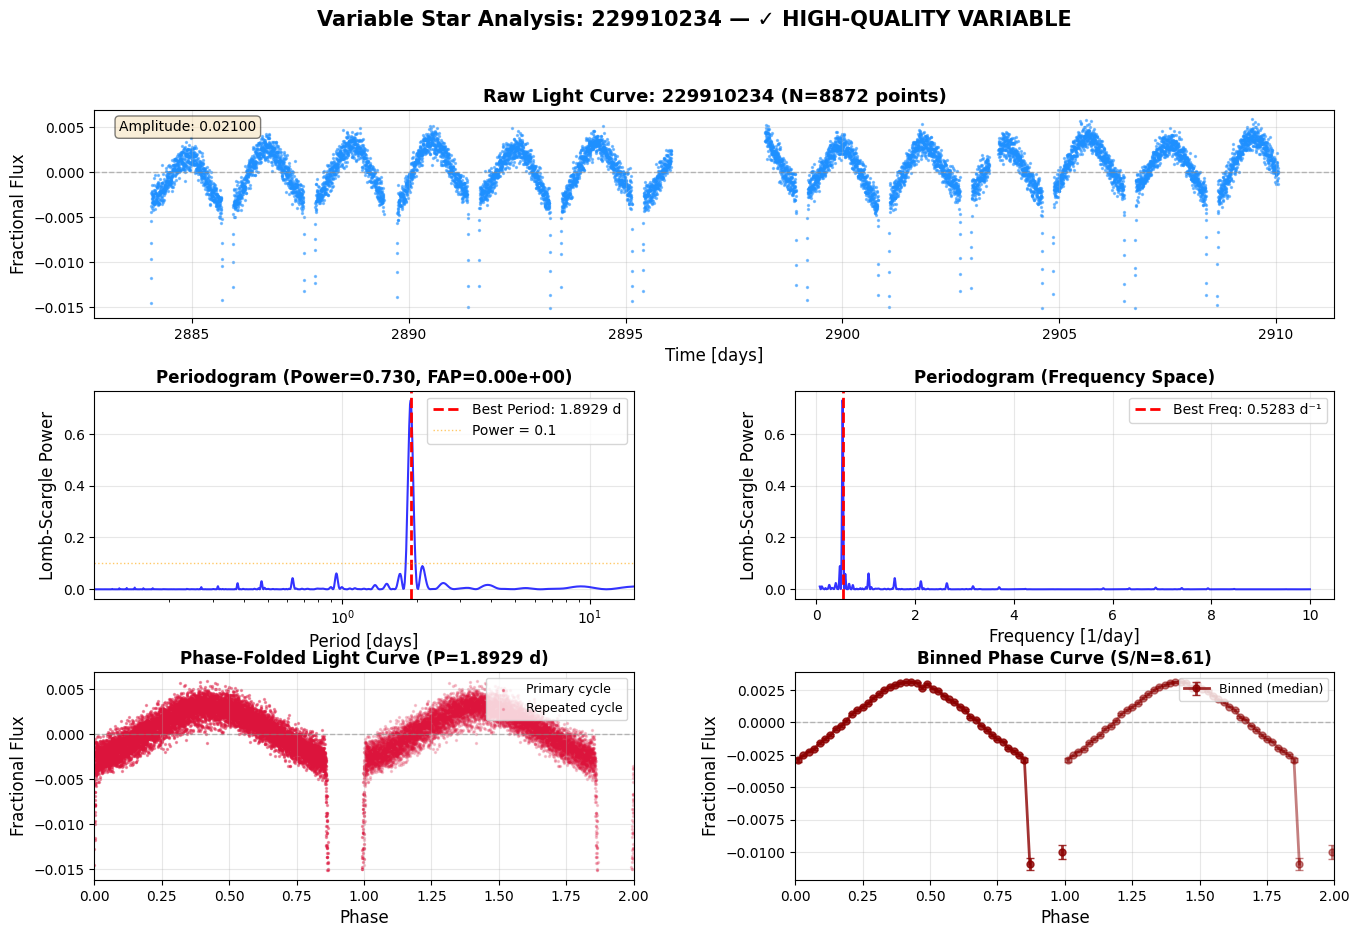



TESS LIGHT CURVE PROPERTIES:
  Period:              1.892878 days
  LS Power:            0.7300  (Strong)
  False Alarm Prob:    0.00e+00  (Significant)
  Amplitude:           0.021004
  Signal-to-Noise:     8.61
  N Points:            8872
  TESS RA, Dec:        287.4042, 61.0644

GAIA DR3 PROPERTIES:
  Source ID:           2251833280070930816
  Separation:          0.200 arcsec
  G magnitude:         10.243
  BP-RP color:         0.660
  B-V (approx):        0.522
  Parallax:            2.4373 ± 0.0117 mas
  Parallax S/N:        208.27
  Distance:            410.3 pc
  RUWE:                1.005
  BP/RP excess:        1.189


HIGH-QUALITY VARIABLE #2


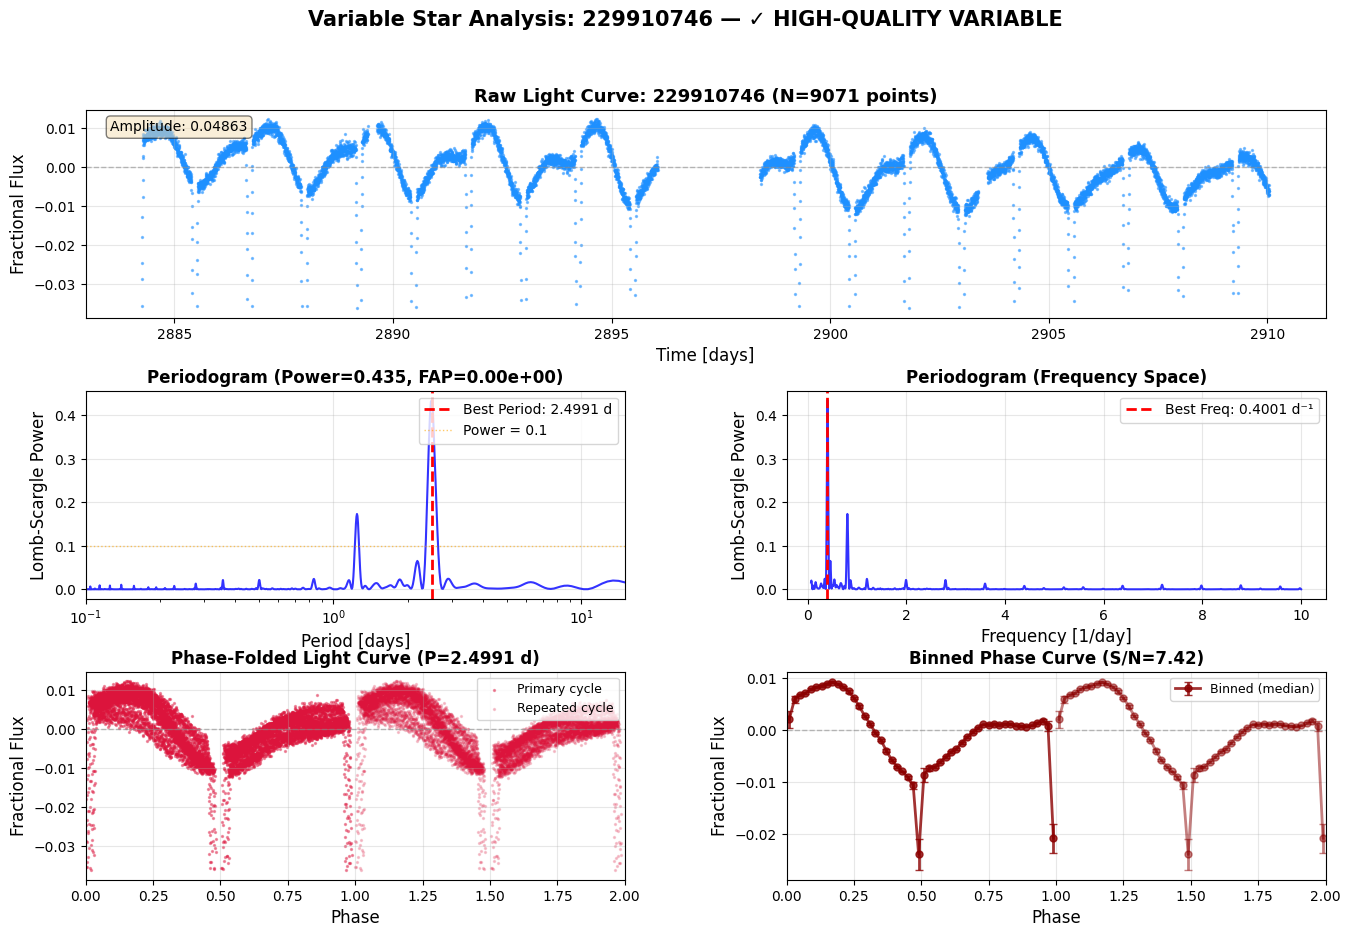



TESS LIGHT CURVE PROPERTIES:
  Period:              2.499117 days
  LS Power:            0.4354  (Strong)
  False Alarm Prob:    0.00e+00  (Significant)
  Amplitude:           0.048629
  Signal-to-Noise:     7.42
  N Points:            9071
  TESS RA, Dec:        287.3495, 61.8378

GAIA DR3 PROPERTIES:
  Source ID:           2252018174119645696
  Separation:          0.506 arcsec
  G magnitude:         10.492
  BP-RP color:         0.762
  B-V (approx):        0.599
  Parallax:            4.2197 ± 0.0395 mas
  Parallax S/N:        106.74
  Distance:            237.0 pc
  RUWE:                2.937
  BP/RP excess:        1.196



In [21]:
if len(high_quality_vars) > 0:
        print("\n" + "#"*70)
        print(f"# ANALYZING {len(high_quality_vars)} HIGH-QUALITY VARIABLE STARS")
        print("#"*70)
        
        for i, star in enumerate(high_quality_vars[:]):  # Show first 3
            print(f"\n{'='*70}")
            print(f"HIGH-QUALITY VARIABLE #{i+1}")
            print('='*70)
            analyze_star_variability(star)

# keys for csv:

object_id, 'skewness', 'kurtosis', 'second_harmonic', 'third_harmonic', 'period', 'amplitude', 'asymmetry_ratio', 'rise_time_fraction', 'bp_rp', 'ruwe'

In [47]:
import csv

# Define the features you want to extract
features = [
    'object_id', 'is_binary', 'skewness', 'kurtosis', 'second_harmonic', 
    'period', 'amplitude', 'asymmetry_ratio', 'rise_time_fraction', 
    'bp_rp', 'second_harmonic_ratio', 'third_harmonic_ratio', 
    'ruwe', 'signal_to_noise', 'parallax'
]

# Features that come from gaia_data
gaia_features = ['bp_rp', 'ruwe', 'parallax']

# Create CSV file
with open('variable_stars_features.csv', 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=features)
    writer.writeheader()
    
    # Process each star
    for star in high_quality_vars:
        row = {}
        
        # Extract main features
        for feature in features:
            if feature in gaia_features:
                # Get from gaia_data nested dictionary
                if star.get('gaia_data') and feature in star['gaia_data']:
                    row[feature] = star['gaia_data'][feature]
                else:
                    row[feature] = None  # Handle missing gaia_data
            else:
                # Get from main dictionary
                row[feature] = star.get(feature)
        
        writer.writerow(row)

print(f"CSV created with {len(high_quality_vars)} stars and {len(features)} features")

CSV created with 1005 stars and 15 features
